# TCCT S82B — Query-Role Semantic Representation Development

这是 S82 失败后的开发阶段，不是新的盲测成功。它不读取或重跑 S82 的 8 个盲测对，也不使用 S82 标签选择候选。

候选仅由 S75D 及更早允许使用的 224 个已见样本，以及深度 2/5 的局部干预开发样本和深度 9/15 的局部干预验证样本决定。通过后只冻结候选；真正的新能力结论留给 S83。


{List, 2, 6, True}
Dataset[{<|Stage -> S82B, Name -> QueryRoleSemanticRepresentationDevelopment, 
 
>     OriginalFrozenModelChanged -> False, CoreChanged -> False, 
 
>     S82BlindRowsLoaded -> False, S82BlindLabelsUsedForSelection -> False, 
 
>     S82BlindTestRerun -> False, PriorS82ProtocolHash -> 
 
>      7695bea7ea07f903615ce01ad6b6a8481d2741ef1ce08fafb0e2d279e39f09bd, 
 
>     PriorS82BlindResultHash -> 
 
>      64be56fb8ef29638666efaf92cdcd03994a43e3328236fd0f7bd73a4808aa58f, 
 
>     PriorS82AAuditResultHash -> 
 
>      bcdcd4ce2882cc0f3ce8e605508e469271f2bdba482b7389795f77a1fb4b6919, 
 
>     StableFrozenArchitectureHash -> 
 
>      d7d16575e25bd1090e35484931dedae9f80254475ee49cd2d79d43f5d4d1355d, 
 
>     DevelopmentTopologyHash -> 
 
>      7269b8ee4fcafffc2ad23e800a8c3cd068284d2f5f8cc2d7133c72d2448e4976, 
 
>     PreflightPassed -> True|>}, TypeSystem`Vector[TypeSystem`Struct[{Stage, Name, 
 
>      OriginalFrozenModelChanged, CoreChanged, S82BlindRowsLoaded, 
 
>      S82BlindLabelsUsedForSelection, S82BlindTestRerun, PriorS82ProtocolHash, 
 
>      PriorS82BlindResultHash, PriorS82AAuditResultHash, StableFrozenArchitectureHash, 
 
>      DevelopmentTopologyHash, PreflightPassed}, 
 
>     {TypeSystem`Atom[String], TypeSystem`Atom[String], 
 
>      TypeSystem`Atom[TypeSystem`Boolean], TypeSystem`Atom[TypeSystem`Boolean], 
 
>      TypeSystem`Atom[TypeSystem`Boolean], TypeSystem`Atom[TypeSystem`Boolean], 
 
>      TypeSystem`Atom[TypeSystem`Boolean], TypeSystem`Atom[String], 
 
>      TypeSystem`Atom[String], TypeSystem`Atom[String], TypeSystem`Atom[String], 
 
>      TypeSystem`Atom[String], TypeSystem`Atom[TypeSystem`Boolean]}], 1], <||>]
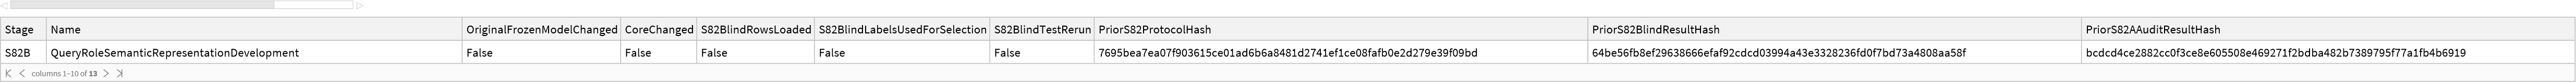

In [5]:





ClearAll["Global`*"];
$HistoryLength=0;

expectedFrozenModelHash79A=
"d6477c370436d09cf3e8cfc8530decd13ebf8bb79120362146ecb419f9d6a6c4";
expectedTopologySpecHash79A=
"b108aa7f2c59c395056fb9124e7d5d9074e39e5e124d0d98011800433e0dd95b";
expectedTopologyImplementationHash79A=
"f27d1ce683317d35a5e9da01536d95c706065810c27462e336cdb76f4a2dab52";
expectedS79BlindResultHash79A=
"b1ebf089e43121a61d4181139d4ba0a8970dc646a7a41425f861cff2e1f8461d";

frozen75D=<|
"Stage"->"S75D",
"Name"->"ValidatedPolicyCompletion",
"Representation"->
"PairedRadius2Radius3WithParentChildCardinality",
"Params"->{-1,0,-1,-1,-1,0,1,-1},
"K"->5,
"TrainingPolicy"->{{3,1},{3,3},{4,3}},
"Policy"->{
{1,3},{2,2},{3,1},{3,2},{3,3},{4,3}
},
"AddedContinueCodes"->{{1,3},{2,2},{3,2}},
"PolicyCompletionUsesValidationLabels"->True,
"FrozenBeforeS76"->True
|>;

P59[a_,b_,n_Integer,s_Integer]:=If[
n<=0,
{DirectedEdge[a,b]},
DirectedEdge@@@Partition[
Join[{a},Range[s,s+n-1],{b}],
2,
1
]
];

A59[t_,fan_Integer,s_Integer]:=Module[{p1,p2,ls},
p1=s+1;
p2=s+2;
ls=Range[s+3,s+2+fan];
Join[
{
DirectedEdge[p2,p1],
DirectedEdge[p1,t]
},
Table[
DirectedEdge[ls[[i]],p2],
{i,Length[ls]}
]
]
];

T59[d_Integer,r_String,a_Integer,seed_Integer]:=Module[
{
bb,K,c,v,q,e,f={},ib,m,safe,u,dum,r1,r2,wrong,
main,perm,anc,i
},
bb=1000000000 seed;
K=bb+1;
c=Table[bb+100+i,{i,4}];
v=Table[bb+200+i,{i,4}];
q=Table[bb+300+i,{i,4}];
e=Flatten[
Table[
{
DirectedEdge[K,c[[i]]],
DirectedEdge[c[[i]],v[[i]]]
},
{i,4}
],
1
];
Do[
ib=bb+20000000 i;
m=ib+1;
safe=ib+2;
u=ib+3;
dum=ib+4;
r1=ib+10;
r2=ib+20;
wrong=c[[1+Mod[i,4]]];
main=Join[
P59[q[[i]],r1,d,ib+1000000],
P59[q[[i]],r2,d,ib+2000000],
{
DirectedEdge[r1,m],
DirectedEdge[r2,m]
},
P59[q[[i]],safe,d+1,ib+3000000]
];
perm=If[
r==="Continue",
{
DirectedEdge[m,c[[i]]],
DirectedEdge[safe,dum],
DirectedEdge[u,wrong]
},
{
DirectedEdge[m,wrong],
DirectedEdge[safe,c[[i]]],
DirectedEdge[u,dum]
}
];
anc=Join[
A59[m,i,bb+970000000+10000 i],
A59[c[[i]],i,bb+980000000+10000 i]
];
e=Join[e,main,perm,anc];
AppendTo[f,m],
{i,4}
];
{{Union[e],q,K,v,c,f},a}
];

Case59[d_Integer,a_Integer,r_String]:=
T59[d,r,a,59000000+100 d+a];

rw60={-9,6,-2,-2,4,2,-2,6,0};

Pack60[c_List]:=Module[
{x=c[[1]],a=c[[2]],e,v,pos,gi,go,pa,ch,id,od,
pin,pout,cin,cout},
e=x[[1]];
v=Union@Join[
Flatten[List@@@e],
x[[2]],
{x[[3]]},
x[[4]],
x[[5]],
x[[6]]
];
pos=AssociationThread[v,Range[Length[v]]];
gi=GroupBy[
Cases[e,DirectedEdge[u_,w_]:>{w,u}],
First->Last
];
go=GroupBy[
Cases[e,DirectedEdge[u_,w_]:>{u,w}],
First->Last
];
pa=(Lookup[pos,Lookup[gi,#,{}]]&)/@v;
ch=(Lookup[pos,Lookup[go,#,{}]]&)/@v;
id=Length/@pa;
od=Length/@ch;
pin=(Total[id[[#]]]&)/@pa;
pout=(Total[od[[#]]]&)/@pa;
cin=(Total[id[[#]]]&)/@ch;
cout=(Total[od[[#]]]&)/@ch;
{
pa,id,od,
Lookup[pos,x[[2,a]]],
Lookup[pos,x[[5]]],
a,
Length[v],
pin,pout,cin,cout,v
}
];

SigLevels61[c_List,rmax_Integer]:=Module[
{p,pa,id,od,n,ch,cur,nxt,levs,j,k,u},
p=Pack60[c];
pa=p[[1]];
id=p[[2]];
od=p[[3]];
n=p[[7]];
ch=Table[{},n];
Do[
Do[
If[u>0,ch[[u]]=Append[ch[[u]],j]],
{u,pa[[j]]}
],
{j,n}
];
cur=AssociationThread[
Range[n],
MapThread[List,{id,od}]
];
levs={cur};
Do[
nxt=AssociationThread[
Range[n],
Table[
{
Lookup[cur,j],
Sort[Lookup[cur,pa[[j]]]],
Sort[Lookup[cur,ch[[j]]]]
},
{j,n}
]
];
AppendTo[levs,nxt];
cur=nxt,
{k,rmax}
];
levs
];

PropagationSafetyCap78[c_List]:=Module[{n},
n=Pack60[c][[7]];
Max[64,2 n+8]
];

RejectTrace78[c_List]:=Module[
{
p,pa,id,od,q,n,pin,pout,cin,cout,h,z,h2,nz,j,k,
aps,ap,pz,o,zv,rf,rd,dd,pg,allow,active=0,
rej={},rounds=0,terminatedNaturally=False,safetyCap
},
p=Pack60[c];
pa=p[[1]];
id=p[[2]];
od=p[[3]];
q=p[[4]];
n=p[[7]];
pin=p[[8]];
pout=p[[9]];
cin=p[[10]];
cout=p[[11]];
safetyCap=Max[64,2 n+8];
h=ConstantArray[0,n];
z=ConstantArray[0,n];
h[[q]]=1;
For[
k=1,
k<=safetyCap,
k++,
rounds=k;
h2=ConstantArray[0,n];
nz=ConstantArray[0,n];
active=0;
Do[
aps=Select[
pa[[j]],
Function[u,u>0&&h[[u]]==1]
];
ap=Length[aps];
If[
ap>0,
pz=Max[z[[aps]]];
o=Boole[ap>1];
zv={0,1,2,1,3,1,3,1}[[1+2 pz+o]];
nz[[j]]=zv;
rf={
1,
Boole[zv>0],
zv,
Sign[pin[[j]]-id[[j]]],
Sign[pout[[j]]-id[[j]]],
Sign[cin[[j]]-id[[j]]],
Sign[cout[[j]]-od[[j]]],
Sign[id[[j]]-od[[j]]],
Sign[pout[[j]]-cin[[j]]]
};
rd=rw60.rf;
dd=1-cin[[j]]+2 cout[[j]];
pg=od[[j]]+2 Boole[zv>0]-zv;
If[rd>0&&dd<=0,AppendTo[rej,{k,j}]];
allow=If[rd>0,dd>0,pg>0];
If[
TrueQ[allow],
h2[[j]]=1;
active++
]
],
{j,n}
];
h=h2;
z=nz;
If[
active==0,
terminatedNaturally=True;
Break[]
]
];
<|
"Rejects"->rej,
"RoundsExecuted"->rounds,
"TerminatedNaturally"->terminatedNaturally,
"SafetyCap"->safetyCap,
"HitSafetyCap"->And[
!TrueQ[terminatedNaturally],
SameQ[rounds,safetyCap]
],
"ActiveAfterLastRound"->active,
"PackedNodeCount"->n
|>
];

DecisionStatePairsFromRejects78[c_List,rej_List]:=Module[
{levels,nodes},
If[Length[rej]==0,Return[{}]];
levels=SigLevels61[c,3];
nodes=rej[[All,2]];
DeleteDuplicates[
Map[
Function[node,
{
Lookup[levels[[3]],node],
Lookup[levels[[4]],node]
}
],
nodes
]
]
];

EncodeRows75[data_List,p_List,k_Integer]:=Module[{rec},
rec[s_]:=rec[s]=If[
MatchQ[s,{_Integer,_Integer}],
1+Mod[s[[1]]+2 s[[2]],k],
Module[
{z,ps,cs,parentSum,childSum,parentSquare,childSquare},
z=rec[s[[1]]];
ps=rec/@s[[2]];
cs=rec/@s[[3]];
parentSum=Total[ps-1];
childSum=Total[cs-1];
parentSquare=Total[(ps-1)^2];
childSquare=Total[(cs-1)^2];
1+Mod[
p[[1]]+
p[[2]](z-1)+
p[[3]]parentSum+
p[[4]]childSum+
p[[5]]parentSquare+
p[[6]]childSquare+
p[[7]]Length[ps]+
p[[8]]Length[cs],
k
]
]
];
Map[
Function[row,
Join[
KeyTake[row,{"Grammar","Depth","Answer","Target"}],
<|
"Codes"->DeleteDuplicates[
Map[
Function[pair,{rec[pair[[1]]],rec[pair[[2]]]}],
row["StatePairs"]
]
]
|>
]
],
data
]
];

DiamondIn72[c_List]:=Module[
{x=c[[1]],a=c[[2]],e,f,mx,next,new,m,incs,rm,
add,s1,s2,g,i,j},
e=x[[1]];
f=x[[6]];
mx=Max@Flatten[List@@@e];
next=mx+1;
new=e;
Do[
m=f[[i]];
incs=Cases[new,DirectedEdge[u_,v_]/;v===m:>{u,v}];
rm=DirectedEdge@@@incs;
add={};
Do[
s1=next;
s2=next+1;
g=next+2;
next=next+3;
add=Join[
add,
{
DirectedEdge[incs[[j,1]],s1],
DirectedEdge[incs[[j,1]],s2],
DirectedEdge[s1,g],
DirectedEdge[s2,g],
DirectedEdge[g,m]
}
],
{j,Length[incs]}
];
new=Join[Complement[new,rm],add],
{i,Length[f]}
];
{{Union[new],x[[2]],x[[3]],x[[4]],x[[5]],x[[6]]},a}
];

DoubleDiamondIn79[c_List]:=Module[
{
x=c[[1]],a=c[[2]],e,f,mx,next,new,m,incs,removed,
added,parent,s1,s2,g1,t1,t2,g2,i,j
},
e=x[[1]];
f=x[[6]];
mx=Max@Flatten[List@@@e];
next=mx+1;
new=e;
Do[
m=f[[i]];
incs=Cases[new,DirectedEdge[u_,v_]/;v===m:>{u,v}];
removed=DirectedEdge@@@incs;
added={};
Do[
parent=incs[[j,1]];
s1=next;
s2=next+1;
g1=next+2;
t1=next+3;
t2=next+4;
g2=next+5;
next=next+6;
added=Join[
added,
{
DirectedEdge[parent,s1],
DirectedEdge[parent,s2],
DirectedEdge[s1,g1],
DirectedEdge[s2,g1],
DirectedEdge[g1,t1],
DirectedEdge[g1,t2],
DirectedEdge[t1,g2],
DirectedEdge[t2,g2],
DirectedEdge[g2,m]
}
],
{j,Length[incs]}
];
new=Join[Complement[new,removed],added],
{i,Length[f]}
];
{{Union[new],x[[2]],x[[3]],x[[4]],x[[5]],x[[6]]},a}
];

Case79[
depth_Integer,
answer_Integer,
target_String
]:=DoubleDiamondIn79[
Case59[depth,answer,target]
];

topologySpec79=<|
"Topology"->"DoubleDiamondIn",
"TransformationScope"->
"EveryIncomingEdgeOfEachDecisionNode",
"Motif"->"TwoSerialPrivateDiamonds",
"CrossParentSharing"->False,
"DiamondsPerOriginalIncomingEdge"->2,
"ParentToDecisionPathLength"->5,
"NewNodesPerOriginalIncomingEdge"->6,
"ReplacementEdgesPerOriginalIncomingEdge"->9,
"EdgeDeltaPerOriginalIncomingEdge"->8,
"ReachabilityPreserved"->True,
"OriginalDecisionNodesPreserved"->True,
"TopologyUsedInS59ThroughS78"->False
|>;

topologySpecHash79=Hash[
Normal[topologySpec79],
"SHA256",
"HexString"
];

topologyImplementationHash79=Hash[
{DownValues[DoubleDiamondIn79],DownValues[Case79]},
"SHA256",
"HexString"
];

modelHash79A=Hash[
Normal[frozen75D],
"SHA256",
"HexString"
];

minimalKernelHash79A=Hash[
{
DownValues[P59],
DownValues[A59],
DownValues[T59],
DownValues[Case59],
OwnValues[rw60],
DownValues[Pack60],
DownValues[SigLevels61],
DownValues[PropagationSafetyCap78],
DownValues[RejectTrace78],
DownValues[DecisionStatePairsFromRejects78],
DownValues[EncodeRows75],
DownValues[DiamondIn72],
DownValues[DoubleDiamondIn79],
DownValues[Case79]
},
"SHA256",
"HexString"
];


ClearAll[
FindPrivateDiamond79B,
CanonicalizePrivateDiamonds79B,
CanonicalCase79B,
CaseByTopology79B,
DecisionIncomingEdgeCount79B,
ExpectedContractions79B
];

FindPrivateDiamond79B[e_List,protected_List]:=Module[
{
vertices,parents,children,harvest,ins,outs,s1,s2,
p1,p2,g
},
vertices=Union@Flatten[List@@@e];
parents=GroupBy[
Cases[e,DirectedEdge[u_,v_]:>{v,u}],
First->Last
];
children=GroupBy[
Cases[e,DirectedEdge[u_,v_]:>{u,v}],
First->Last
];
harvest=Reap[
Do[
If[
!MemberQ[protected,g],
ins=Sort@Lookup[parents,g,{}];
outs=Sort@Lookup[children,g,{}];
If[
Length[ins]===2&&Length[outs]===1,
{s1,s2}=ins;
p1=Sort@Lookup[parents,s1,{}];
p2=Sort@Lookup[parents,s2,{}];
If[
And[
Intersection[protected,{s1,s2,g}]==={},
Length[p1]===1,
SameQ[p1,p2],
SameQ[Sort@Lookup[children,s1,{}],{g}],
SameQ[Sort@Lookup[children,s2,{}],{g}],
DuplicateFreeQ[{First[p1],s1,s2,g,First[outs]}]
],
Sow[{First[p1],s1,s2,g,First[outs]}]
]
]
],
{g,vertices}
]
][[2]];
If[
harvest==={},
Missing["NotFound"],
First@Sort@First[harvest]
]
];

CanonicalizePrivateDiamonds79B[c_List]:=Module[
{
x=c[[1]],a=c[[2]],e,protected,candidate,
parent,s1,s2,g,target,removed,count=0,log={}
},
e=Union[x[[1]]];
protected=Union[
x[[2]],
{x[[3]]},
x[[4]],
x[[5]],
x[[6]]
];
While[
True,
candidate=FindPrivateDiamond79B[e,protected];
If[MissingQ[candidate],Break[]];
{parent,s1,s2,g,target}=candidate;
removed={s1,s2,g};
e=Union[
Select[
e,
Function[edge,
And[
!MemberQ[removed,edge[[1]]],
!MemberQ[removed,edge[[2]]]
]
]
],
{DirectedEdge[parent,target]}
];
count++;
AppendTo[log,candidate]
];
<|
"Case"->{{
e,
x[[2]],
x[[3]],
x[[4]],
x[[5]],
x[[6]]
},a},
"Contractions"->count,
"ContractionLog"->log,
"ProtectedNodesPreserved"->And@@Map[
MemberQ[Union@Flatten[List@@@e],#]&,
protected
]
|>
];

CanonicalCase79B[c_List]:=
CanonicalizePrivateDiamonds79B[c]["Case"];

CaseByTopology79B[
topology_String,
depth_Integer,
answer_Integer,
target_String
]:=Switch[
topology,
"Base",
Case59[depth,answer,target],
"DiamondIn",
DiamondIn72[Case59[depth,answer,target]],
"DoubleDiamondIn",
DoubleDiamondIn79[Case59[depth,answer,target]],
_,
$Failed
];

DecisionIncomingEdgeCount79B[c_List]:=Module[
{e=c[[1,1]],f=c[[1,6]]},
Total[Count[e,DirectedEdge[_,#]]&/@f]
];

ExpectedContractions79B[
topology_String,
baseCase_List
]:=Switch[
topology,
"Base",
0,
"DiamondIn",
DecisionIncomingEdgeCount79B[baseCase],
"DoubleDiamondIn",
2 DecisionIncomingEdgeCount79B[baseCase],
_,
Missing["UnknownTopology"]
];

canonicalizerImplementationHash79B=Hash[
{
DownValues[FindPrivateDiamond79B],
DownValues[CanonicalizePrivateDiamonds79B],
DownValues[CanonicalCase79B]
},
"SHA256",
"HexString"
];


ClearAll[HierarchicalDiamondIn80,Case80];

HierarchicalDiamondIn80[c_List]:=Module[
{
x=c[[1]],a=c[[2]],e,f,mx,next,new,m,incs,removed,
added,parent,s1,s2,g,l1,l2,lg,r1,r2,rg,i,j
},
e=x[[1]];
f=x[[6]];
mx=Max@Flatten[List@@@e];
next=mx+1;
new=e;
Do[
m=f[[i]];
incs=Cases[
new,
DirectedEdge[u_,v_]/;v===m:>{u,v}
];
removed=DirectedEdge@@@incs;
added={};
Do[
parent=incs[[j,1]];
s1=next;
s2=next+1;
g=next+2;
l1=next+3;
l2=next+4;
lg=next+5;
r1=next+6;
r2=next+7;
rg=next+8;
next=next+9;
added=Join[
added,
{
DirectedEdge[parent,l1],
DirectedEdge[parent,l2],
DirectedEdge[l1,lg],
DirectedEdge[l2,lg],
DirectedEdge[lg,s1],
DirectedEdge[parent,r1],
DirectedEdge[parent,r2],
DirectedEdge[r1,rg],
DirectedEdge[r2,rg],
DirectedEdge[rg,s2],
DirectedEdge[s1,g],
DirectedEdge[s2,g],
DirectedEdge[g,m]
}
],
{j,Length[incs]}
];
new=Join[
Complement[new,removed],
added
],
{i,Length[f]}
];
{{
Union[new],
x[[2]],
x[[3]],
x[[4]],
x[[5]],
x[[6]]
},a}
];

Case80[
depth_Integer,
answer_Integer,
target_String
]:=HierarchicalDiamondIn80[
Case59[depth,answer,target]
];

topologySpec80=<|
"Topology"->"HierarchicalDiamondIn",
"TransformationScope"->
"EveryIncomingEdgeOfEachDecisionNode",
"Motif"->
"OuterDiamondWhoseTwoUpperBranchesArePrivateDiamonds",
"CrossParentSharing"->False,
"PrivateDiamondsPerOriginalIncomingEdge"->3,
"HierarchyLevels"->2,
"ParentToDecisionPathLength"->5,
"NewNodesPerOriginalIncomingEdge"->9,
"ReplacementEdgesPerOriginalIncomingEdge"->13,
"EdgeDeltaPerOriginalIncomingEdge"->12,
"ExpectedCanonicalContractionsPerOriginalEdge"->3,
"ReachabilityPreserved"->True,
"OriginalDecisionNodesPreserved"->True,
"PrimitivePrivateDiamondSeenBeforeS80"->True,
"HierarchicalCompositionSeenBeforeS80"->False,
"TopologyUsedBeforeS80"->False
|>;

topologySpecHash80=Hash[
Normal[topologySpec80],
"SHA256",
"HexString"
];

topologyImplementationHash80=Hash[
{
DownValues[HierarchicalDiamondIn80],
DownValues[Case80]
},
"SHA256",
"HexString"
];

ClearAll[ChainIn63, SharedMerge63, Case63];
ChainIn63[c_List]:=Module[
{x=c[[1]], a=c[[2]], e, f, mx, inc, rm, add, new, n},
e=x[[1]];
f=x[[6]];
mx=Max@Flatten[List@@@e];
inc=Cases[
e,
DirectedEdge[u_, v_ ] /; MemberQ[f, v]:>{u, v}
];
rm=DirectedEdge@@@inc;
add=Flatten[
Table[
n=mx+i;
{
DirectedEdge[inc[[i, 1]], n],
DirectedEdge[n, inc[[i, 2]]]
},
{i, Length[inc]}
],
1
];
new=Union[
Join[
Complement[e, rm],
add
]
];
{{new, x[[2]], x[[3]], x[[4]], x[[5]], x[[6]]}, a}
];
SharedMerge63[c_List]:=Module[
{x=c[[1]], a=c[[2]], e, f, mx, new, m, ps, rm, g, i},
e=x[[1]];
f=x[[6]];
mx=Max@Flatten[List@@@e];
new=e;
Do[
m=f[[i]];
ps=Cases[
new,
DirectedEdge[u_, v_ ] /; v===m:>u
];
rm=(DirectedEdge[#, m]&)/@ps;
new=Complement[
new,
rm
];
g=mx+i;
new=Join[
new,
(DirectedEdge[#, g]&)/@ps,
{DirectedEdge[g, m]}
],
{i, Length[f]}
];
{{Union[new], x[[2]], x[[3]], x[[4]], x[[5]], x[[6]]}, a}
];
Case63[
g_String ,
d_Integer,
a_Integer,
t_String
]:=
Switch[
g,
"ChainIn",
ChainIn63[Case59[d, a, t]],
"SharedMerge",
SharedMerge63[Case59[d, a, t]]
];

ClearAll[ParallelIn71];
ParallelIn71[c_List]:=Module[
{x=c[[1]], a=c[[2]], e, f, mx, new, m, incs, rm,
add, next, g1, g2, i, j},
e=x[[1]];
f=x[[6]];
mx=Max@Flatten[List@@@e];
next=mx+1;
new=e;
Do[
m=f[[i]];
incs=Cases[
new,
DirectedEdge[u_, v_ ] /; v===m:>{u, v}
];
rm=DirectedEdge@@@incs;
add= {};
Do[
g1=next;
g2=next+1;
next=next+2;
add=Join[
add,
{
DirectedEdge[incs[[j, 1]], g1],
DirectedEdge[g1, m],
DirectedEdge[incs[[j, 1]], g2],
DirectedEdge[g2, m]
}
],
{j, Length[incs]}
];
new=Join[
Complement[new, rm],
add
],
{i, Length[f]}
];
{{
Union[new],
x[[2]],
x[[3]],
x[[4]],
x[[5]],
x[[6]]
}, a}
];

(* In[408] *)
p71=ParallelIn71[
Case59[2, 1, "Continue"]
];
{
Head[p71],
Length[p71],
Length[p71[[1]]],
Length[p71[[1, 1]]] >
Length[Case59[2, 1, "Continue"][[1, 1]]]
}

(* In[410] *)
ClearAll[Case71];
Case71[
d_Integer,
a_Integer,
t_String
]:=
ParallelIn71[
Case59[d, a, t]
];

ClearAll[ParallelOut72,SharedParallelIn72,Case72B];
ParallelOut72[c_List]:=Module[
{x=c[[1]],a=c[[2]],e,f,mx,next,new,m,outs,rm,
add,g1,g2,i,j},
e=x[[1]];
f=x[[6]];
mx=Max@Flatten[List@@@e];
next=mx+1;
new=e;
Do[
m=f[[i]];
outs=Cases[
new,
DirectedEdge[u_,v_]/;u===m:>{u,v}
];
rm=DirectedEdge@@@outs;
add={};
Do[
g1=next;
g2=next+1;
next=next+2;
add=Join[
add,
{
DirectedEdge[m,g1],
DirectedEdge[g1,outs[[j,2]]],
DirectedEdge[m,g2],
DirectedEdge[g2,outs[[j,2]]]
}
],
{j,Length[outs]}
];
new=Join[
Complement[new,rm],
add
],
{i,Length[f]}
];
{{
Union[new],
x[[2]],x[[3]],x[[4]],x[[5]],x[[6]]
},a}
];

SharedParallelIn72[c_List]:=Module[
{x=c[[1]],a=c[[2]],e,f,mx,next,new,m,ps,rm,
g1,g2,add,i},
e=x[[1]];
f=x[[6]];
mx=Max@Flatten[List@@@e];
next=mx+1;
new=e;
Do[
m=f[[i]];
ps=Cases[
new,
DirectedEdge[u_,v_]/;v===m:>u
];
rm=(DirectedEdge[#,m]&)/@ps;
g1=next;
g2=next+1;
next=next+2;
add=Join[
Flatten[
Table[
{
DirectedEdge[ps[[j]],g1],
DirectedEdge[ps[[j]],g2]
},
{j,Length[ps]}
],
1
],
{
DirectedEdge[g1,m],
DirectedEdge[g2,m]
}
];
new=Join[
Complement[new,rm],
add
],
{i,Length[f]}
];
{{
Union[new],
x[[2]],x[[3]],x[[4]],x[[5]],x[[6]]
},a}
];

Case72B[
topology_String,
depth_Integer,
answer_Integer,
target_String
]:=Switch[
topology,
"ParallelOut",
ParallelOut72[Case59[depth,answer,target]],
"DiamondIn",
DiamondIn72[Case59[depth,answer,target]],
"SharedParallelIn",
SharedParallelIn72[Case59[depth,answer,target]],
_,
$Failed
];



ClearAll[
EdgeSet81,
VertexSet81,
WithEdges81,
EdgePatch81,
ApplyEdgePatch81,
InverseEdgePatch81,
VertexDegreeProfile81,
OppositeAction81
];

EdgeSet81[c_List]:=c[[1,1]];

VertexSet81[c_List]:=Union@Flatten[
List@@@EdgeSet81[c]
];

WithEdges81[c_List,newEdges_List]:=Module[
{x=c[[1]],a=c[[2]]},
{{
Union[newEdges],
x[[2]],
x[[3]],
x[[4]],
x[[5]],
x[[6]]
},a}
];

EdgePatch81[from_List,to_List]:=<|
"Remove"->Complement[
EdgeSet81[from],
EdgeSet81[to]
],
"Add"->Complement[
EdgeSet81[to],
EdgeSet81[from]
]
|>;

ApplyEdgePatch81[c_List,patch_Association]:=Module[
{e,remove,add,valid},
e=EdgeSet81[c];
remove=patch["Remove"];
add=patch["Add"];
valid=And[
And@@Map[MemberQ[e,#]&,remove],
And@@Map[!MemberQ[e,#]&,add],
Intersection[remove,add]==={}
];
If[
!TrueQ[valid],
Return[$Failed]
];
WithEdges81[
c,
Join[Complement[e,remove],add]
]
];

InverseEdgePatch81[patch_Association]:=<|
"Remove"->patch["Add"],
"Add"->patch["Remove"]
|>;

VertexDegreeProfile81[c_List]:=Module[
{e=EdgeSet81[c],vertices},
vertices=VertexSet81[c];
AssociationThread[
vertices,
Map[
Function[node,
{
Count[e,DirectedEdge[_,node]],
Count[e,DirectedEdge[node,_]]
}
],
vertices
]
]
];

OppositeAction81[action_String]:=Switch[
action,
"Continue","Stop",
"Stop","Continue",
_,Missing["UnknownAction"]
];ClearAll[
LocalMediatorSources82,
FullSemanticPatch82,
LocalMediatorPatch82,
PatchSourceSet82,
ReferenceAction82
];

LocalMediatorSources82[c_List]:=Module[
{x=c[[1]],answer=c[[2]],m},
m=x[[6,answer]];
{m,m+1,m+2}
];

FullSemanticPatch82[
depth_Integer,
answer_Integer
]:=EdgePatch81[
Case59[depth,answer,"Continue"],
Case59[depth,answer,"Stop"]
];

LocalMediatorPatch82[
depth_Integer,
answer_Integer
]:=Module[
{factual,fullPatch,sources},
factual=Case59[depth,answer,"Continue"];
fullPatch=FullSemanticPatch82[depth,answer];
sources=LocalMediatorSources82[factual];
<|
"Remove"->Select[
fullPatch["Remove"],
MemberQ[sources,#[[1]]]&
],
"Add"->Select[
fullPatch["Add"],
MemberQ[sources,#[[1]]]&
]
|>
];

PatchSourceSet82[patch_Association]:=Union[
Map[First,patch["Remove"]],
Map[First,patch["Add"]]
];

ReferenceAction82[c_List]:=Module[
{
x=c[[1]],answer=c[[2]],e,m,safe,u,dum,
correct,wrong,continueEdges,stopEdges
},
e=x[[1]];
m=x[[6,answer]];
safe=m+1;
u=m+2;
dum=m+3;
correct=x[[5,answer]];
wrong=x[[5,1+Mod[answer,4]]];
continueEdges={
DirectedEdge[m,correct],
DirectedEdge[safe,dum],
DirectedEdge[u,wrong]
};
stopEdges={
DirectedEdge[m,wrong],
DirectedEdge[safe,correct],
DirectedEdge[u,dum]
};
Which[
And@@Map[MemberQ[e,#]&,continueEdges],
"Continue",
And@@Map[MemberQ[e,#]&,stopEdges],
"Stop",
True,
"Undefined"
]
];

interventionImplementationHash82=Hash[
{
DownValues[LocalMediatorSources82],
DownValues[FullSemanticPatch82],
DownValues[LocalMediatorPatch82],
DownValues[ReferenceAction82]
},
"SHA256",
"HexString"
];expectedMinimalKernelDefinitionTextHash82B=
"d56be85db649ba1ea4118050a019d35a07c28f394396858f1d40a1f90572b922";
expectedCanonicalizerHash82B=
"5e95c90f528a68d1045048e54b5a08809bf54c01b934902faf47f3dc3e5e587d";
expectedStableFrozenArchitectureHash82B=
"d7d16575e25bd1090e35484931dedae9f80254475ee49cd2d79d43f5d4d1355d";
expectedNeutralTopologyHash82B=
"01af33358afe3fcfe876288b6de7c99a89af22599320fec75911661e240bc121";
expectedInterventionHash82B=
"45a4f2364a569f5346c9d007c0da716dc1752193fc68abcb2b6acd88c5af54bf";
expectedS82ProtocolHash82B=
"7695bea7ea07f903615ce01ad6b6a8481d2741ef1ce08fafb0e2d279e39f09bd";
expectedS82BlindResultHash82B=
"64be56fb8ef29638666efaf92cdcd03994a43e3328236fd0f7bd73a4808aa58f";
expectedS82AAuditResultHash82B=
"bcdcd4ce2882cc0f3ce8e605508e469271f2bdba482b7389795f77a1fb4b6919";

ClearAll[CoreDefinitionBundle82B];
CoreDefinitionBundle82B[]:={
DownValues[P59],DownValues[A59],DownValues[T59],DownValues[Case59],
OwnValues[rw60],DownValues[Pack60],DownValues[SigLevels61],
DownValues[PropagationSafetyCap78],DownValues[RejectTrace78],
DownValues[DecisionStatePairsFromRejects78],DownValues[EncodeRows75],
DownValues[DiamondIn72],DownValues[DoubleDiamondIn79],DownValues[Case79]
};

minimalKernelDefinitionTextHash82B=Hash[
ToString[InputForm[CoreDefinitionBundle82B[]]],
"SHA256",
"HexString"
];

stableFrozenArchitectureHash82B=Hash[
{
Normal[frozen75D],
minimalKernelDefinitionTextHash82B,
canonicalizerImplementationHash79B
},
"SHA256",
"HexString"
];

developmentTopologyHash82B=Hash[
{
DownValues[ChainIn63],DownValues[SharedMerge63],DownValues[Case63],
DownValues[ParallelIn71],DownValues[Case71],
DownValues[ParallelOut72],DownValues[SharedParallelIn72],
DownValues[Case72B]
},
"SHA256",
"HexString"
];

preflightPassed82B=And[
SameQ[modelHash79A,expectedFrozenModelHash79A],
SameQ[
minimalKernelDefinitionTextHash82B,
expectedMinimalKernelDefinitionTextHash82B
],
SameQ[
canonicalizerImplementationHash79B,
expectedCanonicalizerHash82B
],
SameQ[
stableFrozenArchitectureHash82B,
expectedStableFrozenArchitectureHash82B
],
SameQ[
topologyImplementationHash80,
expectedNeutralTopologyHash82B
],
SameQ[
interventionImplementationHash82,
expectedInterventionHash82B
]
];

preflight82B=<|
"Stage"->"S82B",
"Name"->"QueryRoleSemanticRepresentationDevelopment",
"OriginalFrozenModelChanged"->False,
"CoreChanged"->False,
"S82BlindRowsLoaded"->False,
"S82BlindLabelsUsedForSelection"->False,
"S82BlindTestRerun"->False,
"PriorS82ProtocolHash"->expectedS82ProtocolHash82B,
"PriorS82BlindResultHash"->expectedS82BlindResultHash82B,
"PriorS82AAuditResultHash"->expectedS82AAuditResultHash82B,
"StableFrozenArchitectureHash"->stableFrozenArchitectureHash82B,
"DevelopmentTopologyHash"->developmentTopologyHash82B,
"PreflightPassed"->preflightPassed82B
|>;

If[
!TrueQ[preflightPassed82B],
Print[Dataset[{preflight82B}]];
Print["S82B aborted: frozen architecture or intervention mismatch."];
Abort[]
];

Dataset[{preflight82B}]


Dataset[{<|Stage -> S82B, Name -> QueryRoleSemanticRepresentationDevelopment, 
 
>     Purpose -> RepairDesignWithoutS82BlindRetuning, 
 
>     LegacyGrammars -> 
 
>      {S59, ChainIn, SharedMerge, ParallelIn, ParallelOut, DiamondIn, SharedParallelIn}\
 
>      , LegacyDepths -> {2, 5, 9, 15}, LegacyExpectedCases -> 224, 
 
>     LocalStressFitDepths -> {2, 5}, LocalStressValidationDepths -> {9, 15}, 
 
>     LocalStressExpectedCases -> 16, 
 
>     CandidateSchemes -> {CodeOnly, QueryFlag, QueryBranchFlag, CoarseRole, ExactRole}, 
 
>     PolicyRule -> ContinueTokensMinusAnyObservedStopTokens, 
 
>     SelectionRule -> 
 
>      LegacyPerfectThenStressFitPerfectThenStressValidationPerfectThenMinimumComplexity\
 
>      , UsesS82InterventionFamilyForDevelopment -> True, UsesS82BlindDepths -> False, 
 
>     UsesS82BlindRows -> False, UsesS82BlindLabels -> False, 
 
>     RerunsS76ThroughS82 -> False, FutureBlindStage -> S83, 
 
>     ProtocolHash -> e4479a7f80f74778011f3fb03967c5dd350224a4f1b85c0d27f74ef0bde07243, 
 
>     NoCaseEvaluatedBeforeProtocolHash -> True|>}, 
 
>   TypeSystem`Vector[TypeSystem`Assoc[TypeSystem`Atom[String], TypeSystem`AnyType, 20], 
 
>    1], <||>]
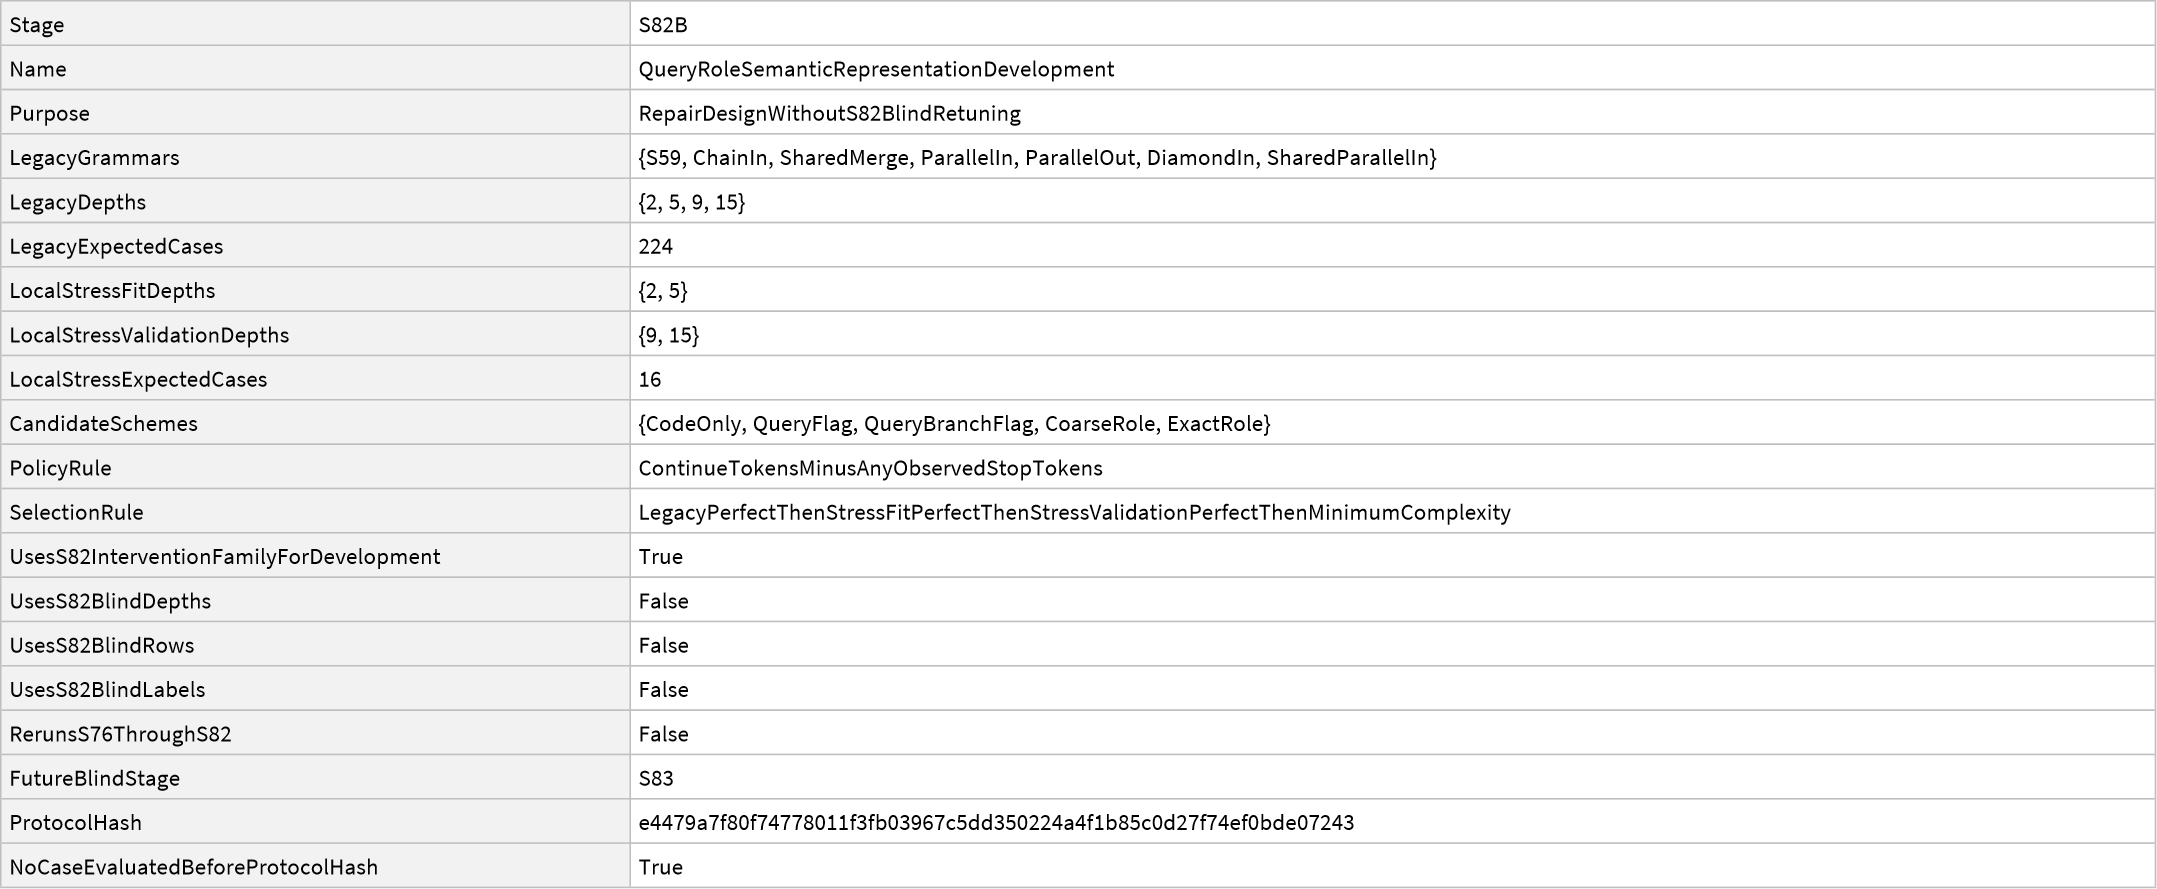

In [93]:
ClearAll[
CaseByGrammar82B,
NodeRole82B,
EncodePair82B,
PrepareRoleRow82B,
TokenizeObservation82B,
TokenizedRows82B,
SafePolicy82B,
PredictRoleTokens82B,
ScoreRoleRows82B,
EvaluateScheme82B
];

legacyGrammars82B={
"S59","ChainIn","SharedMerge","ParallelIn",
"ParallelOut","DiamondIn","SharedParallelIn"
};
legacyDepths82B={2,5,9,15};
stressFitDepths82B={2,5};
stressValidationDepths82B={9,15};
roleSchemes82B={
"CodeOnly",
"QueryFlag",
"QueryBranchFlag",
"CoarseRole",
"ExactRole"
};
schemeComplexity82B=<|
"CodeOnly"->0,
"QueryFlag"->1,
"QueryBranchFlag"->1,
"CoarseRole"->2,
"ExactRole"->3
|>;

protocol82B=<|
"Stage"->"S82B",
"Name"->"QueryRoleSemanticRepresentationDevelopment",
"Purpose"->"RepairDesignWithoutS82BlindRetuning",
"LegacyGrammars"->legacyGrammars82B,
"LegacyDepths"->legacyDepths82B,
"LegacyExpectedCases"->224,
"LocalStressFitDepths"->stressFitDepths82B,
"LocalStressValidationDepths"->stressValidationDepths82B,
"LocalStressExpectedCases"->16,
"CandidateSchemes"->roleSchemes82B,
"PolicyRule"->"ContinueTokensMinusAnyObservedStopTokens",
"SelectionRule"->
"LegacyPerfectThenStressFitPerfectThenStressValidationPerfectThenMinimumComplexity",
"UsesS82InterventionFamilyForDevelopment"->True,
"UsesS82BlindDepths"->False,
"UsesS82BlindRows"->False,
"UsesS82BlindLabels"->False,
"RerunsS76ThroughS82"->False,
"FutureBlindStage"->"S83"
|>;

protocolHash82B=Hash[
Normal[protocol82B],
"SHA256",
"HexString"
];

modelHashBefore82B=Hash[Normal[frozen75D],"SHA256","HexString"];
coreHashBefore82B=Hash[CoreDefinitionBundle82B[],"SHA256","HexString"];
coreTextHashBefore82B=minimalKernelDefinitionTextHash82B;
canonicalizerHashBefore82B=canonicalizerImplementationHash79B;
interventionHashBefore82B=interventionImplementationHash82;
protocolHashBefore82B=protocolHash82B;

Dataset[{Join[
protocol82B,
<|
"ProtocolHash"->protocolHash82B,
"NoCaseEvaluatedBeforeProtocolHash"->True
|>
]}]


Dataset[{<|LegacyCases -> 224, LegacyCasesByGrammar -> 
 
>      <|S59 -> 32, ChainIn -> 32, SharedMerge -> 32, ParallelIn -> 32, 
 
>       ParallelOut -> 32, DiamondIn -> 32, SharedParallelIn -> 32|>, 
 
>     StressFitCases -> 8, StressValidationCases -> 8, 
 
>     AllRowsTerminatedNaturally -> True, RowsHitSafetyCap -> 0|>}, 
 
>   TypeSystem`Vector[TypeSystem`Struct[{LegacyCases, LegacyCasesByGrammar, 
 
>      StressFitCases, StressValidationCases, AllRowsTerminatedNaturally, 
 
>      RowsHitSafetyCap}, {TypeSystem`Atom[Integer], 
 
>      TypeSystem`Assoc[TypeSystem`Atom[TypeSystem`Enumeration[ChainIn, DiamondIn, 
 
>         ParallelIn, ParallelOut, S59, SharedMerge, SharedParallelIn]], 
 
>       TypeSystem`Atom[Integer], 7], TypeSystem`Atom[Integer], 
 
>      TypeSystem`Atom[Integer], TypeSystem`Atom[TypeSystem`Boolean], 
 
>      TypeSystem`Atom[Integer]}], 1], <||>]
Dataset[{<|Scheme -> CodeOnly, Complexity -> 0, PolicyLength -> 3, 
 
>     FitSemanticConflictTokens -> {{2, 2}, {3, 2}}, LegacyScore -> 208, 
 
>     LegacyCases -> 224, StressFitScore -> 8, StressFitCases -> 8, 
 
>     StressValidationScore -> 8, StressValidationCases -> 8, Eligible -> False|>, 
 
>    <|Scheme -> QueryFlag, Complexity -> 1, PolicyLength -> 6, 
 
>     FitSemanticConflictTokens -> {{Other, {3, 2}}}, LegacyScore -> 216, 
 
>     LegacyCases -> 224, StressFitScore -> 8, StressFitCases -> 8, 
 
>     StressValidationScore -> 8, StressValidationCases -> 8, Eligible -> False|>, 
 
>    <|Scheme -> QueryBranchFlag, Complexity -> 1, PolicyLength -> 3, 
 
>     FitSemanticConflictTokens -> {{QueryBranch, {2, 2}}, {QueryBranch, {3, 2}}}, 
 
>     LegacyScore -> 208, LegacyCases -> 224, StressFitScore -> 8, StressFitCases -> 8, 
 
>     StressValidationScore -> 8, StressValidationCases -> 8, Eligible -> False|>, 
 
>    <|Scheme -> CoarseRole, Complexity -> 2, PolicyLength -> 6, 
 
>     FitSemanticConflictTokens -> {{QueriedBranchOther, {3, 2}}}, LegacyScore -> 216, 
 
>     LegacyCases -> 224, StressFitScore -> 8, StressFitCases -> 8, 
 
>     StressValidationScore -> 8, StressValidationCases -> 8, Eligible -> False|>, 
 
>    <|Scheme -> ExactRole, Complexity -> 3, PolicyLength -> 6, 
 
>     FitSemanticConflictTokens -> {{QueriedCorrectDestination, {3, 2}}}, 
 
>     LegacyScore -> 216, LegacyCases -> 224, StressFitScore -> 8, StressFitCases -> 8, 
 
>     StressValidationScore -> 8, StressValidationCases -> 8, Eligible -> False|>}, 
 
>   TypeSystem`Vector[TypeSystem`Struct[{Scheme, Complexity, PolicyLength, 
 
>      FitSemanticConflictTokens, LegacyScore, LegacyCases, StressFitScore, 
 
>      StressFitCases, StressValidationScore, StressValidationCases, Eligible}, 
 
>     {TypeSystem`Atom[String], TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], 
 
>      TypeSystem`Vector[TypeSystem`Tuple[{TypeSystem`AnyType, TypeSystem`AnyType}], 
 
>       TypeSystem`AnyLength], TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], 
 
>      TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], 
 
>      TypeSystem`Atom[Integer], TypeSystem`Atom[TypeSystem`Boolean]}], 5], <||>]
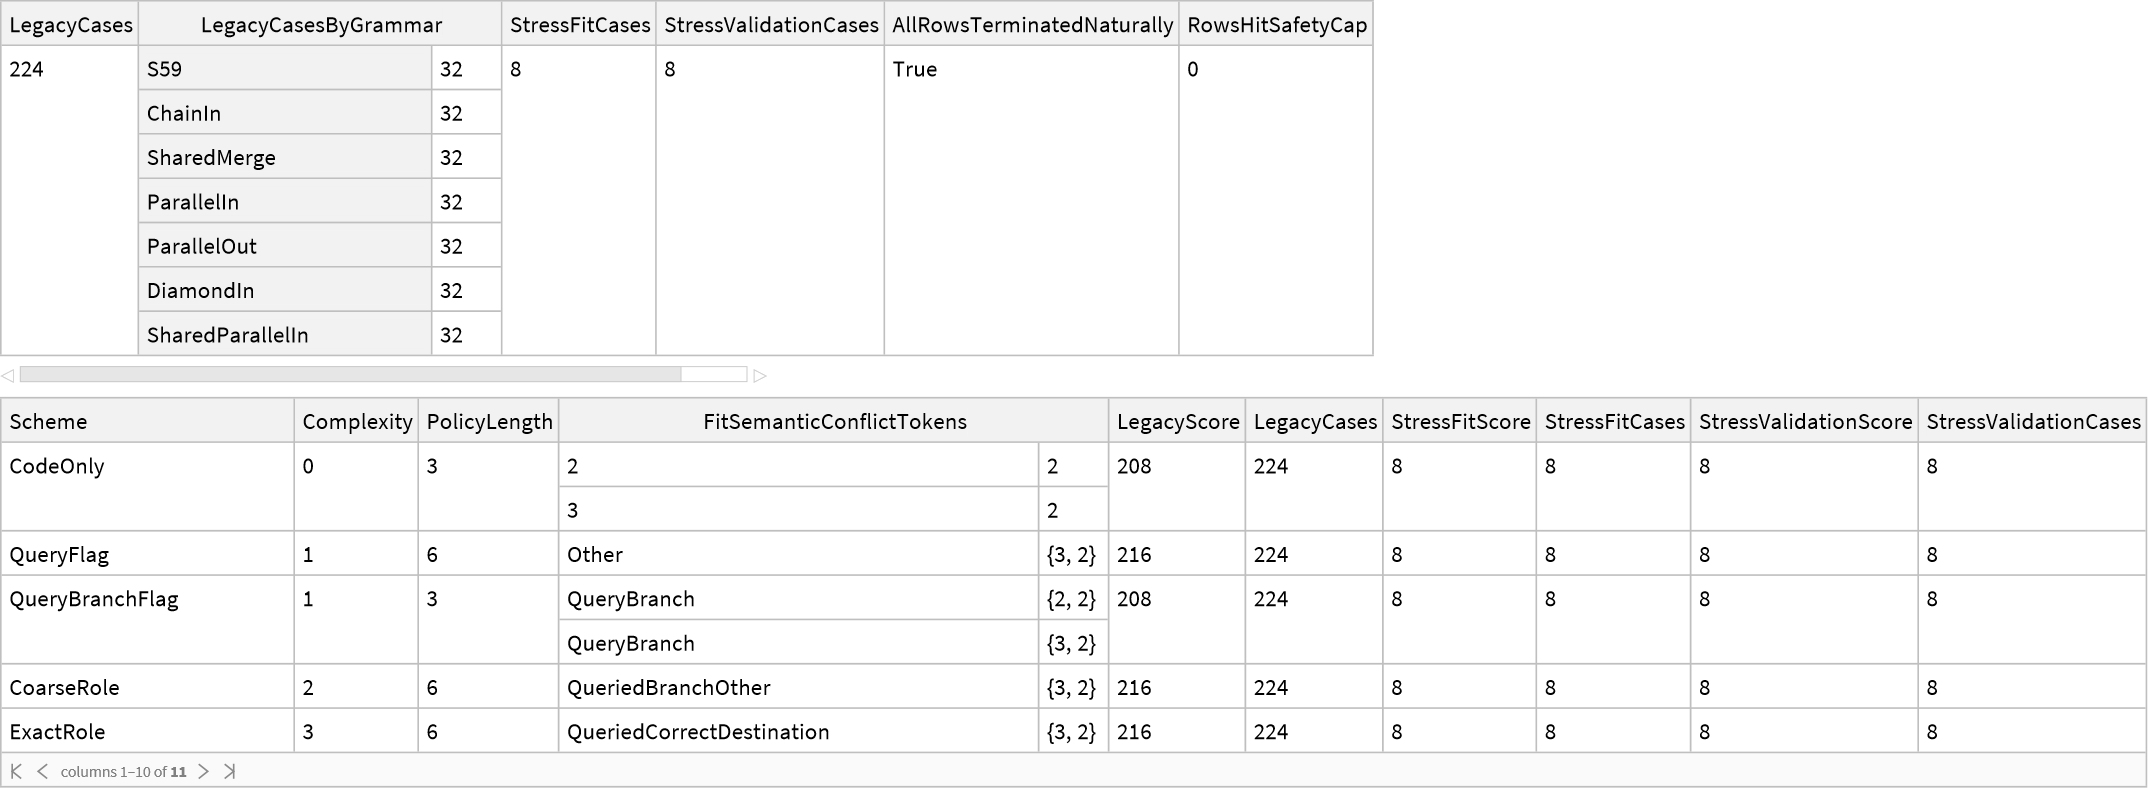

In [109]:
CaseByGrammar82B[
grammar_String,
depth_Integer,
answer_Integer,
target_String
]:=Switch[
grammar,
"S59",Case59[depth,answer,target],
"ChainIn",Case63["ChainIn",depth,answer,target],
"SharedMerge",Case63["SharedMerge",depth,answer,target],
"ParallelIn",Case71[depth,answer,target],
"ParallelOut"|"DiamondIn"|"SharedParallelIn",
Case72B[grammar,depth,answer,target],
_,$Failed
];

NodeRole82B[
originalNode_,
case_List,
answer_Integer
]:=Module[
{x,m,correct,wrong,dummy,querySources,queryBranch,role},
x=case[[1]];
m=x[[6,answer]];
correct=x[[5,answer]];
wrong=x[[5,1+Mod[answer,4]]];
dummy=m+3;
querySources={m,m+1,m+2};
queryBranch=Union[querySources,{correct,wrong,dummy}];
role=Which[
SameQ[originalNode,m],"QueriedDecision",
MemberQ[querySources,originalNode],"QueriedMediatorSource",
SameQ[originalNode,correct],"QueriedCorrectDestination",
SameQ[originalNode,wrong],"QueriedWrongDestination",
SameQ[originalNode,dummy],"QueriedDummyDestination",
MemberQ[x[[6]],originalNode],"OtherDecision",
MemberQ[x[[5]],originalNode],"OtherAnswerDestination",
True,"OtherReject"
];
<|
"Role"->role,
"QueryBranchRelated"->MemberQ[queryBranch,originalNode]
|>
];

EncodePair82B[pair_List]:=Module[{encoded},
encoded=First@EncodeRows75[
{<|
"Grammar"->"S82BRoleObservation",
"Depth"->0,
"Answer"->0,
"Target"->"Unlabeled",
"StatePairs"->{pair}
|>},
frozen75D["Params"],
frozen75D["K"]
];
First[encoded["Codes"]]
];

PrepareRoleRow82B[
grammar_String,
depth_Integer,
answer_Integer,
target_String,
case_List
]:=Module[
{
canonicalization,canonicalCase,trace,levels,pack,vertexList,
packedNodes,observations,roleInfo,pair,code,originalNode
},
canonicalization=CanonicalizePrivateDiamonds79B[case];
canonicalCase=canonicalization["Case"];
trace=RejectTrace78[canonicalCase];
levels=SigLevels61[canonicalCase,3];
pack=Pack60[canonicalCase];
vertexList=pack[[12]];
packedNodes=If[
Length[trace["Rejects"]]===0,
{},
DeleteDuplicates[trace["Rejects"][[All,2]]]
];
observations=Map[
Function[packedNode,
originalNode=vertexList[[packedNode]];
pair={
Lookup[levels[[3]],packedNode],
Lookup[levels[[4]],packedNode]
};
code=EncodePair82B[pair];
roleInfo=NodeRole82B[originalNode,canonicalCase,answer];
<|
"PackedNode"->packedNode,
"OriginalNode"->originalNode,
"Role"->roleInfo["Role"],
"QueryBranchRelated"->roleInfo["QueryBranchRelated"],
"RawPairHash"->Hash[pair,"SHA256","HexString"],
"Code"->code
|>
],
packedNodes
];
<|
"Grammar"->grammar,
"Depth"->depth,
"Answer"->answer,
"Target"->target,
"TerminatedNaturally"->trace["TerminatedNaturally"],
"HitSafetyCap"->trace["HitSafetyCap"],
"CanonicalizationContractions"->canonicalization["Contractions"],
"Observations"->observations
|>
];

TokenizeObservation82B[observation_Association,scheme_String]:=Module[
{code,role,branch,coarse},
code=observation["Code"];
role=observation["Role"];
branch=observation["QueryBranchRelated"];
coarse=Which[
SameQ[role,"QueriedDecision"],"QueriedDecision",
TrueQ[branch],"QueriedBranchOther",
True,"Other"
];
Switch[
scheme,
"CodeOnly",code,
"QueryFlag",{If[SameQ[role,"QueriedDecision"],"Query","Other"],code},
"QueryBranchFlag",{If[TrueQ[branch],"QueryBranch","Other"],code},
"CoarseRole",{coarse,code},
"ExactRole",{role,code},
_,$Failed
]
];

TokenizedRows82B[rows_List,scheme_String]:=Map[
Function[row,
Join[
KeyTake[row,{"Grammar","Depth","Answer","Target"}],
<|
"Tokens"->DeleteDuplicates[
TokenizeObservation82B[#,scheme]&/@row["Observations"]
]
|>
]
],
rows
];

SafePolicy82B[tokenRows_List]:=Module[
{continueRows,stopRows,continueTokens,stopTokens},
continueRows=Select[tokenRows,SameQ[#["Target"],"Continue"]&];
stopRows=Select[tokenRows,SameQ[#["Target"],"Stop"]&];
continueTokens=Union@@Lookup[continueRows,"Tokens"];
stopTokens=Union@@Lookup[stopRows,"Tokens"];
Complement[continueTokens,stopTokens]
];

PredictRoleTokens82B[tokens_List,policy_List]:=If[
AnyTrue[tokens,MemberQ[policy,#]&],
"Continue",
"Stop"
];

ScoreRoleRows82B[tokenRows_List,policy_List]:=Count[
tokenRows,
row_/;SameQ[
PredictRoleTokens82B[row["Tokens"],policy],
row["Target"]
]
];

legacyRows82B=Flatten[
Table[
PrepareRoleRow82B[
grammar,depth,answer,target,
CaseByGrammar82B[grammar,depth,answer,target]
],
{grammar,legacyGrammars82B},
{depth,legacyDepths82B},
{answer,Range[4]},
{target,{"Continue","Stop"}}
],
3
];

stressFitRows82B=Flatten[
Table[
PrepareRoleRow82B[
"LocalMediatorDevelopment",depth,answer,"Stop",
ApplyEdgePatch81[
Case59[depth,answer,"Continue"],
LocalMediatorPatch82[depth,answer]
]
],
{depth,stressFitDepths82B},
{answer,Range[4]}
],
1
];

stressValidationRows82B=Flatten[
Table[
PrepareRoleRow82B[
"LocalMediatorValidation",depth,answer,"Stop",
ApplyEdgePatch81[
Case59[depth,answer,"Continue"],
LocalMediatorPatch82[depth,answer]
]
],
{depth,stressValidationDepths82B},
{answer,Range[4]}
],
1
];

fitRows82B=Join[legacyRows82B,stressFitRows82B];

EvaluateScheme82B[scheme_String]:=Module[
{
legacyTokenRows,stressFitTokenRows,stressValidationTokenRows,
fitTokenRows,policy,legacyScore,stressFitScore,stressValidationScore,
fitContinueTokens,fitStopTokens
},
legacyTokenRows=TokenizedRows82B[legacyRows82B,scheme];
stressFitTokenRows=TokenizedRows82B[stressFitRows82B,scheme];
stressValidationTokenRows=TokenizedRows82B[
stressValidationRows82B,scheme
];
fitTokenRows=Join[legacyTokenRows,stressFitTokenRows];
policy=SafePolicy82B[fitTokenRows];
legacyScore=ScoreRoleRows82B[legacyTokenRows,policy];
stressFitScore=ScoreRoleRows82B[stressFitTokenRows,policy];
stressValidationScore=ScoreRoleRows82B[
stressValidationTokenRows,policy
];
fitContinueTokens=Union@@Lookup[
Select[fitTokenRows,SameQ[#["Target"],"Continue"]&],
"Tokens"
];
fitStopTokens=Union@@Lookup[
Select[fitTokenRows,SameQ[#["Target"],"Stop"]&],
"Tokens"
];
<|
"Scheme"->scheme,
"Complexity"->schemeComplexity82B[scheme],
"Policy"->policy,
"PolicyLength"->Length[policy],
"FitSemanticConflictTokens"->Intersection[
fitContinueTokens,fitStopTokens
],
"LegacyScore"->legacyScore,
"LegacyCases"->Length[legacyTokenRows],
"StressFitScore"->stressFitScore,
"StressFitCases"->Length[stressFitTokenRows],
"StressValidationScore"->stressValidationScore,
"StressValidationCases"->Length[stressValidationTokenRows],
"Eligible"->And[
SameQ[legacyScore,Length[legacyTokenRows]],
SameQ[stressFitScore,Length[stressFitTokenRows]],
SameQ[stressValidationScore,Length[stressValidationTokenRows]]
]
|>
];

schemeResults82B=EvaluateScheme82B/@roleSchemes82B;
eligibleSchemes82B=Select[schemeResults82B,TrueQ[#["Eligible"]]&];
selectedScheme82B=If[
Length[eligibleSchemes82B]>0,
First@SortBy[
eligibleSchemes82B,
{#["Complexity"],#["PolicyLength"],#["Scheme"]}&
],
Missing["NoEligibleScheme"]
];

dataSummary82B=<|
"LegacyCases"->Length[legacyRows82B],
"LegacyCasesByGrammar"->Counts@Lookup[legacyRows82B,"Grammar"],
"StressFitCases"->Length[stressFitRows82B],
"StressValidationCases"->Length[stressValidationRows82B],
"AllRowsTerminatedNaturally"->And@@Lookup[
Join[legacyRows82B,stressFitRows82B,stressValidationRows82B],
"TerminatedNaturally"
],
"RowsHitSafetyCap"->Count[
Join[legacyRows82B,stressFitRows82B,stressValidationRows82B],
row_/;TrueQ[row["HitSafetyCap"]]
]
|>;

Column[{
Dataset[{dataSummary82B}],
Dataset[Map[KeyDrop[#,"Policy"]&,schemeResults82B]]
}]


Dataset[{<|Stage -> S82B, Name -> QueryRoleSemanticRepresentationDevelopment, 
 
>     Meaning -> PostS82RepairDevelopmentNotANewBlindCounterfactualSuccess, 
 
>     CasesEvaluated -> 240, EligibleSchemeCount -> 0, 
 
>     SelectedScheme -> Missing[NoEligibleScheme], 
 
>     SelectedPolicyLength -> Missing[NoPolicy], 
 
>     SelectedLegacyScore -> Missing[NoScore], 
 
>     SelectedStressFitScore -> Missing[NoScore], 
 
>     SelectedStressValidationScore -> Missing[NoScore], 
 
>     OriginalFrozenModelChanged -> False, CoreChanged -> False, 
 
>     CanonicalizerChanged -> False, InterventionChanged -> False, 
 
>     S82BlindRowsLoaded -> False, S82BlindLabelsUsedForSelection -> False, 
 
>     S82BlindTestRerun -> False, S82BIsBlindTest -> False, 
 
>     DevelopmentValidityPassed -> True, SelectionSucceeded -> False, 
 
>     CandidateHash -> Missing[NoCandidateHash], ReadyForNewS83BlindTest -> False, 
 
>     SuggestedNextStage -> 
 
>      S82C_REPRESENTATION_CAPACITY_DIAGNOSIS_WITHOUT_S82_BLIND_LABELS|>}, 
 
>   TypeSystem`Vector[TypeSystem`Assoc[TypeSystem`Atom[String], TypeSystem`AnyType, 23], 
 
>    1], <||>]
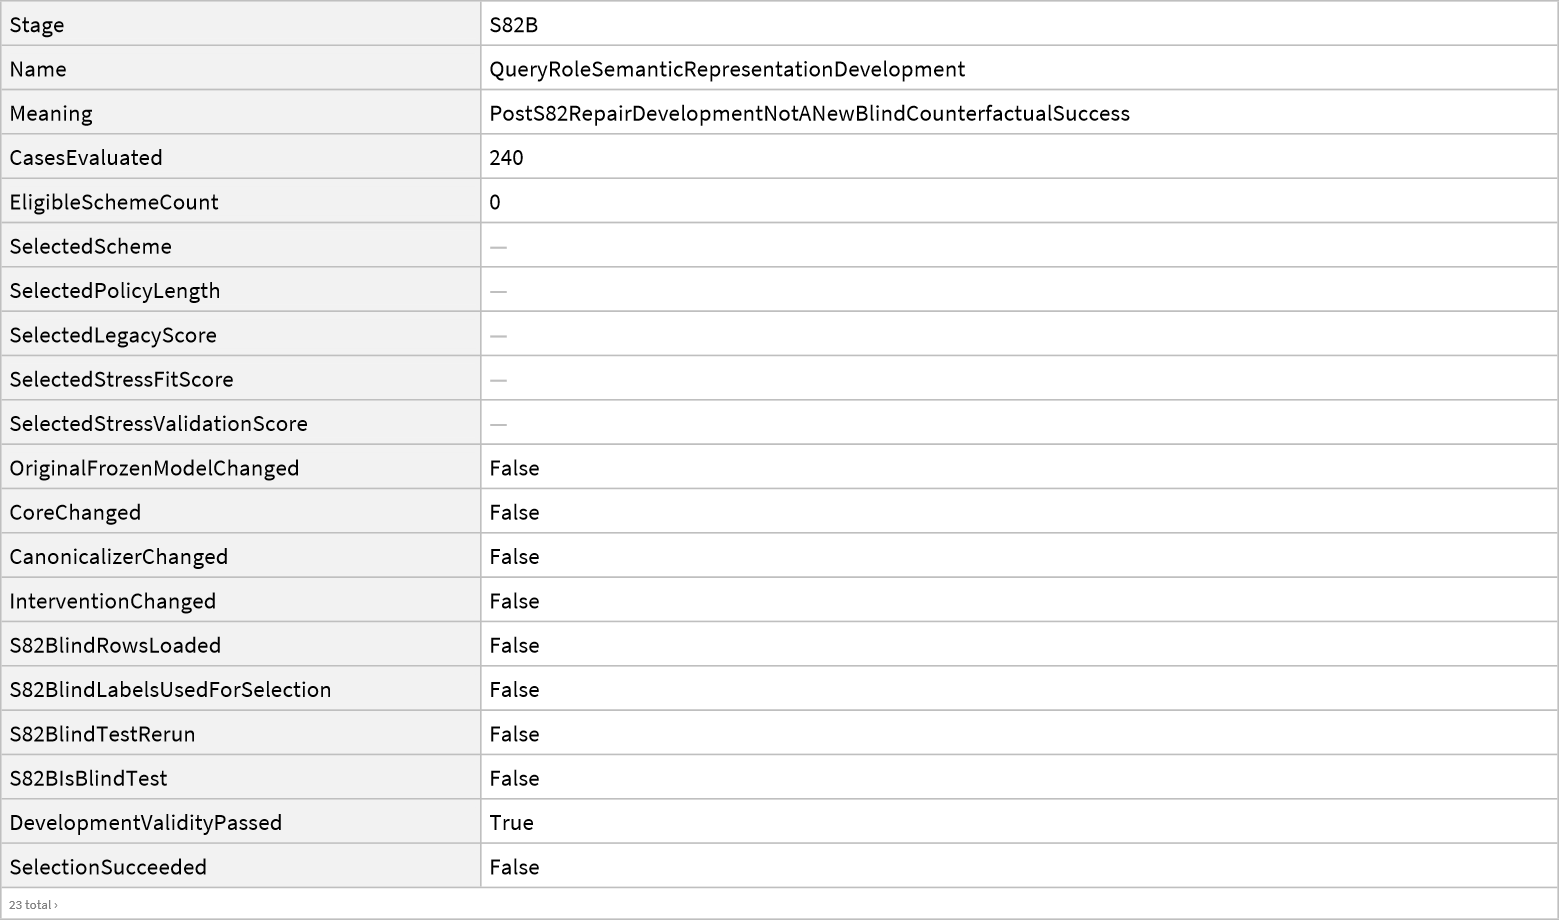

In [128]:
modelHashAfter82B=Hash[Normal[frozen75D],"SHA256","HexString"];
coreHashAfter82B=Hash[CoreDefinitionBundle82B[],"SHA256","HexString"];
coreTextHashAfter82B=Hash[
ToString[InputForm[CoreDefinitionBundle82B[]]],
"SHA256",
"HexString"
];
canonicalizerHashAfter82B=Hash[
{
DownValues[FindPrivateDiamond79B],
DownValues[CanonicalizePrivateDiamonds79B],
DownValues[CanonicalCase79B]
},
"SHA256",
"HexString"
];
interventionHashAfter82B=Hash[
{
DownValues[LocalMediatorSources82],
DownValues[FullSemanticPatch82],
DownValues[LocalMediatorPatch82],
DownValues[ReferenceAction82]
},
"SHA256",
"HexString"
];
protocolHashAfter82B=Hash[Normal[protocol82B],"SHA256","HexString"];

integrityPassed82B=And[
SameQ[modelHashBefore82B,modelHashAfter82B],
SameQ[modelHashAfter82B,expectedFrozenModelHash79A],
SameQ[coreHashBefore82B,coreHashAfter82B],
SameQ[coreTextHashBefore82B,coreTextHashAfter82B],
SameQ[
coreTextHashAfter82B,
expectedMinimalKernelDefinitionTextHash82B
],
SameQ[canonicalizerHashBefore82B,canonicalizerHashAfter82B],
SameQ[canonicalizerHashAfter82B,expectedCanonicalizerHash82B],
SameQ[interventionHashBefore82B,interventionHashAfter82B],
SameQ[interventionHashAfter82B,expectedInterventionHash82B],
SameQ[protocolHashBefore82B,protocolHashAfter82B]
];

developmentValidityPassed82B=And[
TrueQ[preflightPassed82B],
TrueQ[integrityPassed82B],
SameQ[Length[legacyRows82B],224],
SameQ[Length[stressFitRows82B],8],
SameQ[Length[stressValidationRows82B],8],
TrueQ[dataSummary82B["AllRowsTerminatedNaturally"]],
SameQ[dataSummary82B["RowsHitSafetyCap"],0]
];

selectionSucceeded82B=And[
TrueQ[developmentValidityPassed82B],
AssociationQ[selectedScheme82B],
TrueQ[selectedScheme82B["Eligible"]]
];

frozenCandidate82B=If[
TrueQ[selectionSucceeded82B],
<|
"Stage"->"S82B",
"Name"->"QueryRoleSemanticRepresentationCandidate",
"BaseFrozenModelHash"->expectedFrozenModelHash79A,
"EncoderParams"->frozen75D["Params"],
"K"->frozen75D["K"],
"RoleScheme"->selectedScheme82B["Scheme"],
"RolePolicy"->selectedScheme82B["Policy"],
"SelectionUsesS82BlindLabels"->False,
"FrozenBeforeS83"->True
|>,
Missing["NoCandidateFrozen"]
];

candidateHash82B=If[
AssociationQ[frozenCandidate82B],
Hash[Normal[frozenCandidate82B],"SHA256","HexString"],
Missing["NoCandidateHash"]
];

cert82B=<|
"Stage"->"S82B",
"Name"->"QueryRoleSemanticRepresentationDevelopment",
"Meaning"->
"PostS82RepairDevelopmentNotANewBlindCounterfactualSuccess",
"CasesEvaluated"->(
Length[legacyRows82B]+Length[stressFitRows82B]+
Length[stressValidationRows82B]
),
"EligibleSchemeCount"->Length[eligibleSchemes82B],
"SelectedScheme"->If[
AssociationQ[selectedScheme82B],
selectedScheme82B["Scheme"],
selectedScheme82B
],
"SelectedPolicyLength"->If[
AssociationQ[selectedScheme82B],
selectedScheme82B["PolicyLength"],
Missing["NoPolicy"]
],
"SelectedLegacyScore"->If[
AssociationQ[selectedScheme82B],
{selectedScheme82B["LegacyScore"],selectedScheme82B["LegacyCases"]},
Missing["NoScore"]
],
"SelectedStressFitScore"->If[
AssociationQ[selectedScheme82B],
{selectedScheme82B["StressFitScore"],selectedScheme82B["StressFitCases"]},
Missing["NoScore"]
],
"SelectedStressValidationScore"->If[
AssociationQ[selectedScheme82B],
{
selectedScheme82B["StressValidationScore"],
selectedScheme82B["StressValidationCases"]
},
Missing["NoScore"]
],
"OriginalFrozenModelChanged"->!SameQ[
modelHashBefore82B,modelHashAfter82B
],
"CoreChanged"->!SameQ[coreHashBefore82B,coreHashAfter82B],
"CanonicalizerChanged"->!SameQ[
canonicalizerHashBefore82B,canonicalizerHashAfter82B
],
"InterventionChanged"->!SameQ[
interventionHashBefore82B,interventionHashAfter82B
],
"S82BlindRowsLoaded"->False,
"S82BlindLabelsUsedForSelection"->False,
"S82BlindTestRerun"->False,
"S82BIsBlindTest"->False,
"DevelopmentValidityPassed"->developmentValidityPassed82B,
"SelectionSucceeded"->selectionSucceeded82B,
"CandidateHash"->candidateHash82B,
"ReadyForNewS83BlindTest"->selectionSucceeded82B,
"SuggestedNextStage"->If[
TrueQ[selectionSucceeded82B],
"S83_FREEZE_CANDIDATE_THEN_NEW_INTERVENTION_BLIND_TEST",
"S82C_REPRESENTATION_CAPACITY_DIAGNOSIS_WITHOUT_S82_BLIND_LABELS"
]
|>;

Dataset[{cert82B}]
